In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

from ultralytics import YOLO

In [2]:
MODEL_PATH = (
    "/Volumes/Extreme Pro/Files/Github/Applied_cv/bdd100k-perception/runs/detect/outputs/training/yolov8n_bdd100k/weights/best.pt"
)

model = YOLO(MODEL_PATH)

In [3]:
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
  

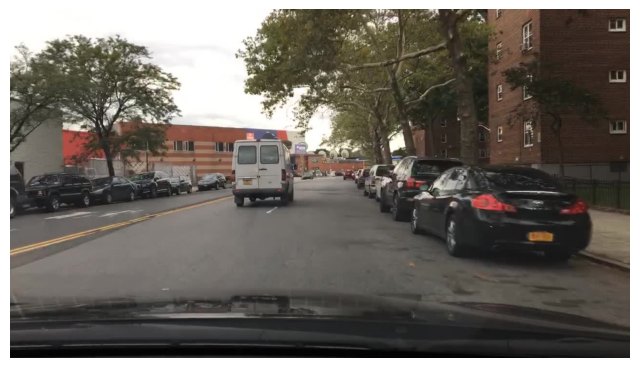

In [5]:
IMG_PATH = (
    "/Volumes/Extreme Pro/Files/Github/Applied_cv/datasets/bdd100k/images/100k/val/b1c9c847-3bda4659.jpg"
)

img_bgr = cv2.imread(IMG_PATH)

img_rgb = cv2.cvtColor(
    img_bgr,
    cv2.COLOR_BGR2RGB,
)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [6]:
feature_maps = {}
def get_activation(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach().cpu()

    return hook

In [7]:
model.model.model[0].register_forward_hook(
    get_activation("conv1")
)

model.model.model[2].register_forward_hook(
    get_activation("c2f1")
)

model.model.model[4].register_forward_hook(
    get_activation("c2f2")
)

model.model.model[7].register_forward_hook(
    get_activation("sppf")
)

In [8]:
_ = model.predict(
    source=IMG_PATH,
    verbose=False
)

In [9]:
for name, fmap in feature_maps.items():
    print(name, fmap.shape)

conv1 torch.Size([1, 16, 192, 320])
c2f1 torch.Size([1, 32, 96, 160])
c2f2 torch.Size([1, 64, 48, 80])
sppf torch.Size([1, 256, 12, 20])


In [12]:
conv1 = feature_maps["conv1"][0]
conv1
print(conv1.shape)

torch.Size([16, 192, 320])


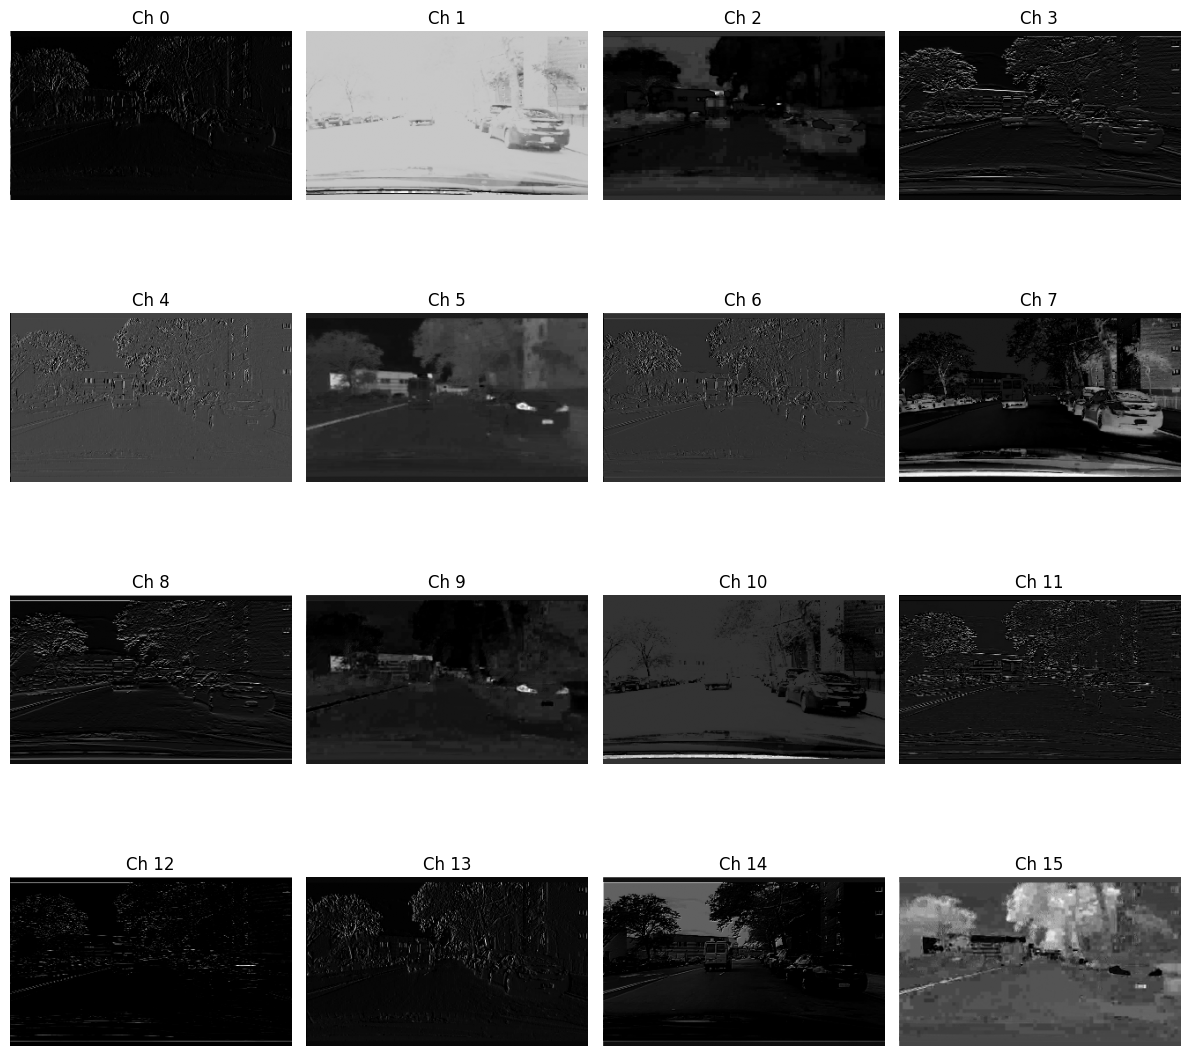

In [13]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        conv1[i],
        cmap="gray"
    )

    ax.set_title(f"Ch {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
first_conv = model.model.model[0]

weights = (
    first_conv.conv.weight
    .detach()
    .cpu()
)
print(weights.shape)

torch.Size([16, 3, 3, 3])


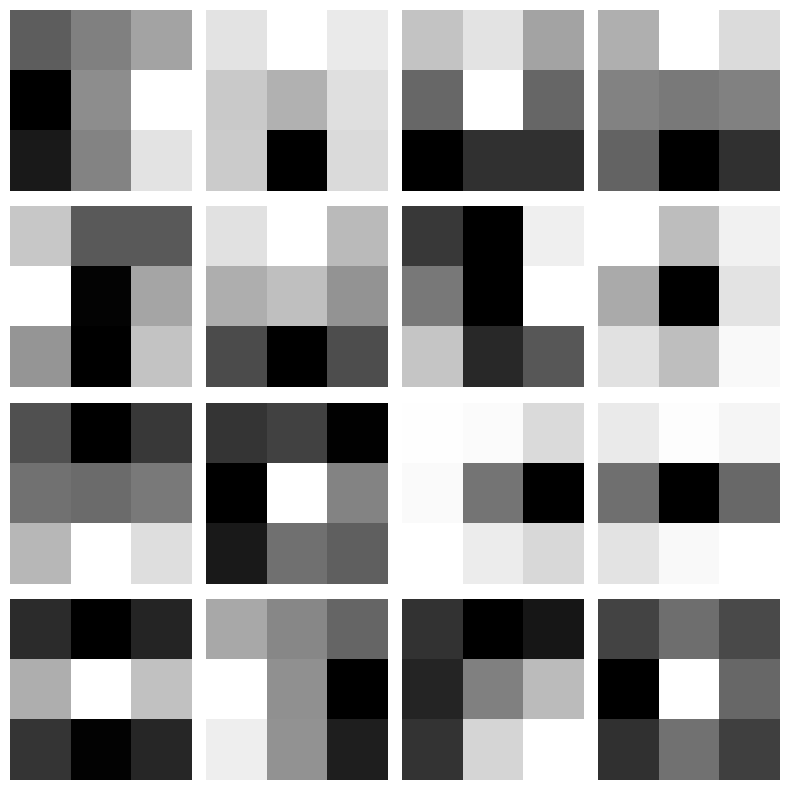

In [15]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(8, 8)
)

for i, ax in enumerate(axes.flat):

    kernel = weights[i]

    kernel = kernel.mean(0)

    ax.imshow(
        kernel,
        cmap="gray"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()